# 02 - Weather and Load Relationships

This notebook tests how temperature, wind speed, and wind direction relate to aggregate reefer load.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path("/Users/omkarsomeshwarkondhalkar/Movies/project/eurogate")
DATA_DIR = ROOT / "participant_package"
WEATHER_DIR = DATA_DIR / "Wetterdaten Okt 25 - 23 Feb 26"

# Semicolon-separated reefer file with decimal commas.
reefer = pd.read_csv(
    DATA_DIR / "reefer_release.csv",
    sep=";",
    usecols=["EventTime", "AvPowerCons"],
    parse_dates=["EventTime"],
    low_memory=False,
)
reefer["AvPowerCons"] = pd.to_numeric(reefer["AvPowerCons"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

hourly = (reefer.assign(power_kw=reefer["AvPowerCons"] / 1000)
          .groupby("EventTime", as_index=False)
          .agg(total_power_kw=("power_kw", "sum"))
          .rename(columns={"EventTime": "timestamp_utc"}))

weather_files = sorted(WEATHER_DIR.glob("*.csv"))
print("Weather files:", [f.name for f in weather_files])
print("Hourly rows:", len(hourly))

Weather files: ['CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26.csv', 'CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26.csv', 'CTH_Wind_VC_Halle3  Okt 25 - 23 Feb 26.csv', 'CTH_Wind_Zentralgate  Okt 25 - 23 Feb 26.csv', 'CTH_Windrichtung_VC_Halle3  Okt 25 - 23 Feb 26.csv', 'CTH_Windrichtung_Zentralgate  Okt 25 - 23 Feb 26.csv']
Hourly rows: 8403


In [2]:
def read_weather_file(path: Path):
    # Auto-detect delimiter to handle German exports (; , tab)
    w = pd.read_csv(path, sep=None, engine="python")

    time_col_candidates = [c for c in w.columns if "time" in c.lower() or "datum" in c.lower() or "date" in c.lower()]
    val_col_candidates = [c for c in w.columns if c not in time_col_candidates]
    if not time_col_candidates or not val_col_candidates:
        return None

    tcol = time_col_candidates[0]
    vcol = val_col_candidates[-1]
    tmp = w[[tcol, vcol]].copy()
    tmp.columns = ["timestamp_utc", path.stem]
    tmp["timestamp_utc"] = pd.to_datetime(tmp["timestamp_utc"], errors="coerce", utc=True).dt.tz_convert(None)
    tmp[path.stem] = pd.to_numeric(tmp[path.stem].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    return tmp.dropna(subset=["timestamp_utc"])

weather_frames = [read_weather_file(f) for f in weather_files]
weather_frames = [w for w in weather_frames if w is not None]

weather = weather_frames[0]
for w in weather_frames[1:]:
    weather = weather.merge(w, on="timestamp_utc", how="outer")

weather = weather.sort_values("timestamp_utc")
print(weather.head())
print(weather.shape)

                  timestamp_utc  CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26   
0       2025-09-24 10:00:50.943                                         13.2  \
3678450 2025-10-10 09:49:34.283                                          NaN   
235065  2025-10-10 09:49:36.237                                          NaN   
3678451 2025-10-10 09:49:37.280                                          NaN   
235066  2025-10-10 09:49:39.230                                          NaN   

         CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26   
0                                                  13.2  \
3678450                                             NaN   
235065                                              NaN   
3678451                                             NaN   
235066                                              NaN   

         CTH_Wind_VC_Halle3  Okt 25 - 23 Feb 26   
0                                           2.5  \
3678450                                     NaN   
235065     

total_power_kw                                      1.0
CTH_Wind_Zentralgate  Okt 25 - 23 Feb 26           -1.0
CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26         NaN
CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26      NaN
CTH_Wind_VC_Halle3  Okt 25 - 23 Feb 26              NaN
CTH_Windrichtung_VC_Halle3  Okt 25 - 23 Feb 26      NaN
CTH_Windrichtung_Zentralgate  Okt 25 - 23 Feb 26    NaN
Name: total_power_kw, dtype: float64
total_power_kw                                      1.0
CTH_Wind_Zentralgate  Okt 25 - 23 Feb 26           -1.0
CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26         NaN
CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26      NaN
CTH_Wind_VC_Halle3  Okt 25 - 23 Feb 26              NaN
CTH_Windrichtung_VC_Halle3  Okt 25 - 23 Feb 26      NaN
CTH_Windrichtung_Zentralgate  Okt 25 - 23 Feb 26    NaN
Name: total_power_kw, dtype: float64


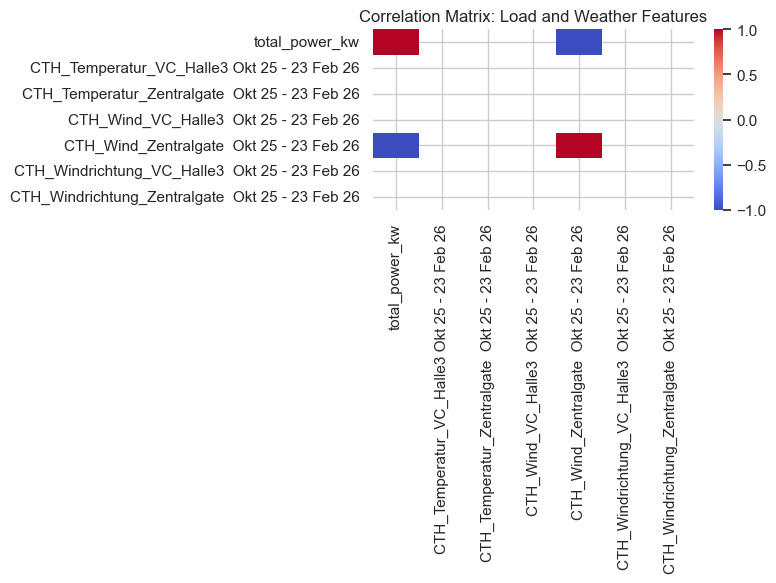

In [3]:
merged = hourly.merge(weather, on="timestamp_utc", how="left")

# Correlation with load
corr = merged.select_dtypes(include=[np.number]).corr(numeric_only=True)["total_power_kw"].sort_values(ascending=False)
print(corr.head(15))
print(corr.tail(15))

plt.figure(figsize=(8, 6))
sns.heatmap(merged.select_dtypes(include=[np.number]).corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Load and Weather Features")
plt.tight_layout()
plt.show()

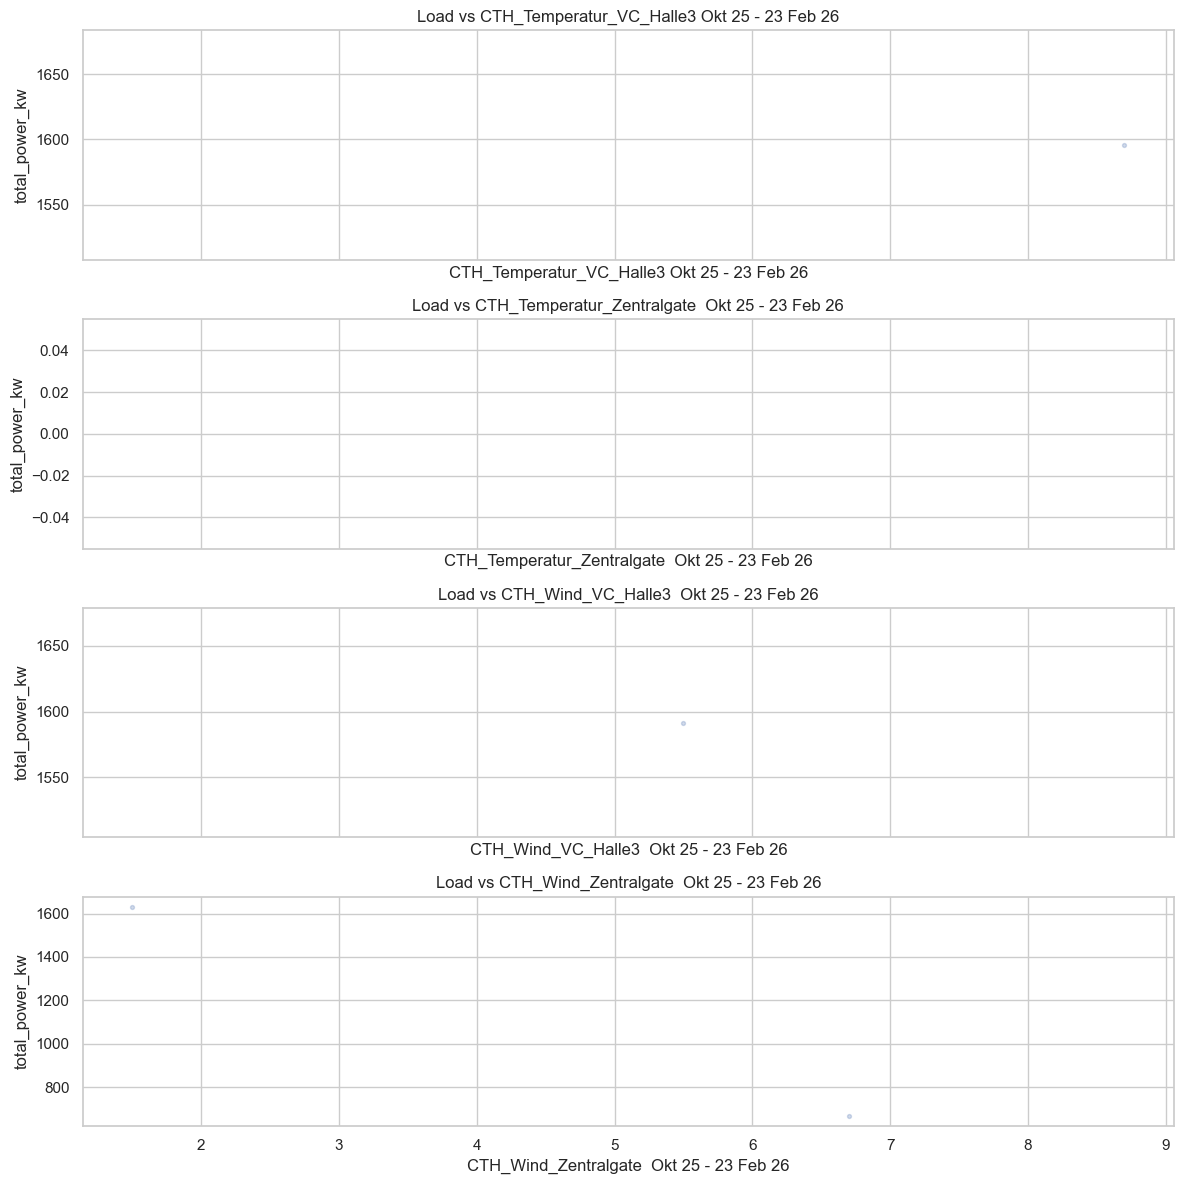

In [4]:
candidate_weather_cols = [c for c in merged.columns if c not in ["timestamp_utc", "total_power_kw"]]
plot_cols = candidate_weather_cols[:4]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(12, 3 * max(1, len(plot_cols))), sharex=True)
if len(plot_cols) == 1:
    axes = [axes]

for ax, c in zip(axes, plot_cols):
    ax.scatter(merged[c], merged["total_power_kw"], s=8, alpha=0.25)
    ax.set_title(f"Load vs {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("total_power_kw")

plt.tight_layout()
plt.show()

In [5]:
# Lagged weather effect test (simple)
for lag in [1, 3, 6, 12, 24]:
    for c in plot_cols[:2]:
        merged[f"{c}_lag{lag}"] = merged[c].shift(lag)

lag_corr = merged[["total_power_kw"] + [c for c in merged.columns if "_lag" in c]].corr(numeric_only=True)["total_power_kw"].sort_values(ascending=False)
lag_corr.head(20)

total_power_kw                                          1.0
CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26_lag1        NaN
CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26_lag1     NaN
CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26_lag3        NaN
CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26_lag3     NaN
CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26_lag6        NaN
CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26_lag6     NaN
CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26_lag12       NaN
CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26_lag12    NaN
CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26_lag24       NaN
CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26_lag24    NaN
Name: total_power_kw, dtype: float64